In [ ]:
import sys

# Проверяем, запущен ли ноутбук в среде Google Colab
if 'google.colab' in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_1/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q

<img src="../pic/CU.png" style="width: 100%; display: block; margin: auto;">

# Курс по прогнозированию временных рядов

## Семинар 1. Пункт 2 — Виды временных рядов

Временные ряды встречаются в самых разных «формах». От того, как устроены данные, зависит и способ их хранения, и выбор модели. Посмотрим на практике на четыре типичные структуры:

1. **Univariate** — один ряд (одна величина во времени).
2. **Panel (одномерный)** — много однотипных рядов (много «экземпляров»/сегментов).
3. **Panel Multivariate** — для каждого экземпляра несколько измеряемых величин (в т.ч. экзогенные факторы).
4. **Hierarchical / grouped** — ряды с иерархической/групповой структурой (агрегируются по уровням).

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (23, 9)

## 1. Univariate — один ряд

Самый простой случай. Обычно есть две колонки:
- `timestamp` — время измерения;
- `target` — значение измерения.

Возьмём помесячные продажи австралийского вина.

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/examples_data/monthly-australian-wine-sales.csv")
df.head()

,month,sales
0,1980-01-01,15136
1,1980-02-01,16733
2,1980-03-01,20016
3,1980-04-01,17708
4,1980-05-01,18019


Колонку времени сделаем индексом — так удобнее брать срезы и строить графики.

In [3]:
df["month"] = pd.to_datetime(df["month"])
df = df.set_index("month")

Срез по датам работает прямо по индексу:

In [4]:
df["1980-05-01":"1985-05-01"]

,sales
month,
1980-05-01,18019
1980-06-01,19227
1980-07-01,22893
1980-08-01,23739
1980-09-01,21133
...,...
1985-01-01,18450
1985-02-01,21845
1985-03-01,26488


Нарисуем ряд. Что сразу видно? (растущий тренд и годовая сезонность)

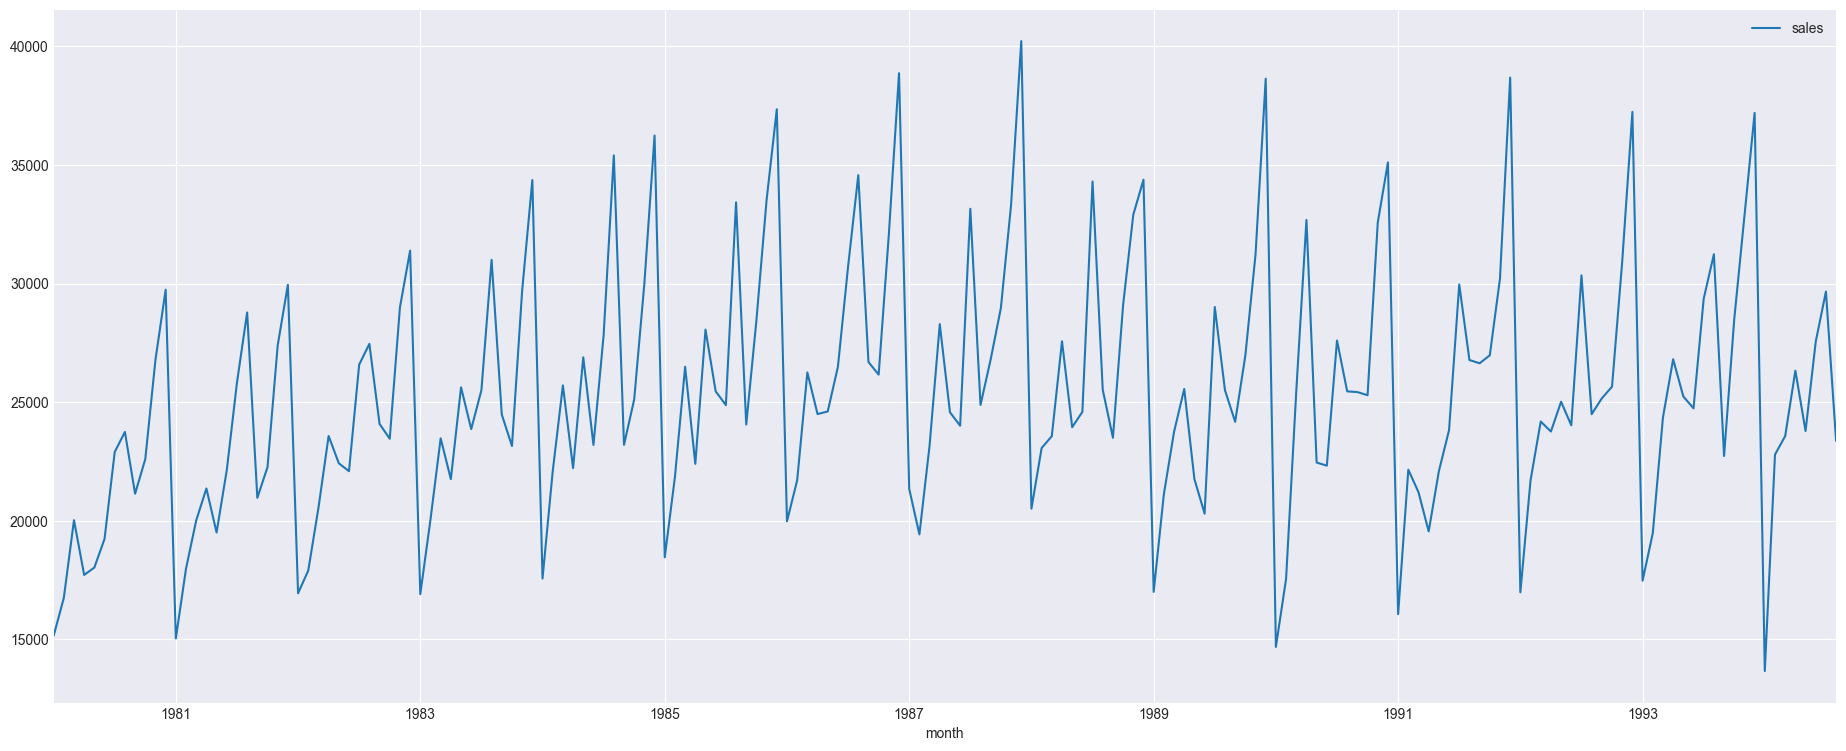

In [5]:
df.plot();

## 2. Panel (одномерный) — много рядов

Часто у нас не один ряд, а множество однотипных. Колонки:
- `timestamp` — время;
- `segment` — колонка (или группа колонок), обозначающая «экземпляр»;
- `target` — значение.

Возьмём продажи мерча в скандинавских странах.

In [6]:
df_panel = pd.read_csv("https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/examples_data/nordic_merch_sales.csv")
df_panel.head()

,timestamp,target,segment
0,2015-01-01,329,Finland_KaggleMart_Kaggle Mug
1,2015-01-01,520,Finland_KaggleMart_Kaggle Hat
2,2015-01-01,146,Finland_KaggleMart_Kaggle Sticker
3,2015-01-01,572,Finland_KaggleRama_Kaggle Mug
4,2015-01-01,911,Finland_KaggleRama_Kaggle Hat


Приведём к «широкому» виду: строки — время, столбцы — сегменты.

In [7]:
df_panel["timestamp"] = pd.to_datetime(df_panel["timestamp"])
df_panel = df_panel.pivot(index="timestamp", columns="segment", values="target")
df_panel.head()

segment,Finland_KaggleMart_Kaggle Hat,Finland_KaggleMart_Kaggle Mug,Finland_KaggleMart_Kaggle Sticker,Finland_KaggleRama_Kaggle Hat,Finland_KaggleRama_Kaggle Mug,Finland_KaggleRama_Kaggle Sticker,Norway_KaggleMart_Kaggle Hat,Norway_KaggleMart_Kaggle Mug,Norway_KaggleMart_Kaggle Sticker,Norway_KaggleRama_Kaggle Hat,Norway_KaggleRama_Kaggle Mug,Norway_KaggleRama_Kaggle Sticker,Sweden_KaggleMart_Kaggle Hat,Sweden_KaggleMart_Kaggle Mug,Sweden_KaggleMart_Kaggle Sticker,Sweden_KaggleRama_Kaggle Hat,Sweden_KaggleRama_Kaggle Mug,Sweden_KaggleRama_Kaggle Sticker
timestamp,,,,,,,,,,,,,,,,,,
2015-01-01,520,329,146,911,572,283,906,526,250,1461,1005,395,624,440,175,1195,706,324
2015-01-02,493,318,127,794,544,249,845,538,237,1446,949,415,572,384,155,986,653,293
2015-01-03,535,360,141,843,579,265,930,614,254,1631,1029,451,630,420,173,1167,734,319
2015-01-04,544,332,125,873,582,245,889,589,255,1540,957,455,697,406,169,1112,657,300
2015-01-05,378,243,102,668,423,187,671,435,184,1126,739,310,442,298,127,796,512,227


In [8]:
df_panel["2016-05-01":"2017-05-01"]

segment,Finland_KaggleMart_Kaggle Hat,Finland_KaggleMart_Kaggle Mug,Finland_KaggleMart_Kaggle Sticker,Finland_KaggleRama_Kaggle Hat,Finland_KaggleRama_Kaggle Mug,Finland_KaggleRama_Kaggle Sticker,Norway_KaggleMart_Kaggle Hat,Norway_KaggleMart_Kaggle Mug,Norway_KaggleMart_Kaggle Sticker,Norway_KaggleRama_Kaggle Hat,Norway_KaggleRama_Kaggle Mug,Norway_KaggleRama_Kaggle Sticker,Sweden_KaggleMart_Kaggle Hat,Sweden_KaggleMart_Kaggle Mug,Sweden_KaggleMart_Kaggle Sticker,Sweden_KaggleRama_Kaggle Hat,Sweden_KaggleRama_Kaggle Mug,Sweden_KaggleRama_Kaggle Sticker
timestamp,,,,,,,,,,,,,,,,,,
2016-05-01,455,204,115,798,347,196,701,332,169,1310,565,335,531,212,125,976,429,199
2016-05-02,399,160,84,653,299,155,542,256,151,1103,446,246,414,190,101,746,322,176
2016-05-03,383,167,88,701,287,143,601,233,141,1092,494,263,456,203,104,825,374,200
2016-05-04,400,166,84,669,306,169,661,263,154,1106,520,247,487,223,101,844,333,194
2016-05-05,414,172,84,655,335,183,667,309,156,1211,543,299,459,219,115,865,365,196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-04-27,406,165,93,735,313,168,641,287,148,1251,529,240,468,203,111,869,358,186
2017-04-28,410,183,101,787,316,167,681,275,161,1226,505,275,467,222,109,822,333,192
2017-04-29,484,205,125,822,373,193,800,340,191,1396,614,294,599,261,141,962,423,253


Если нарисовать все ряды разом, картинка получается перегруженной:

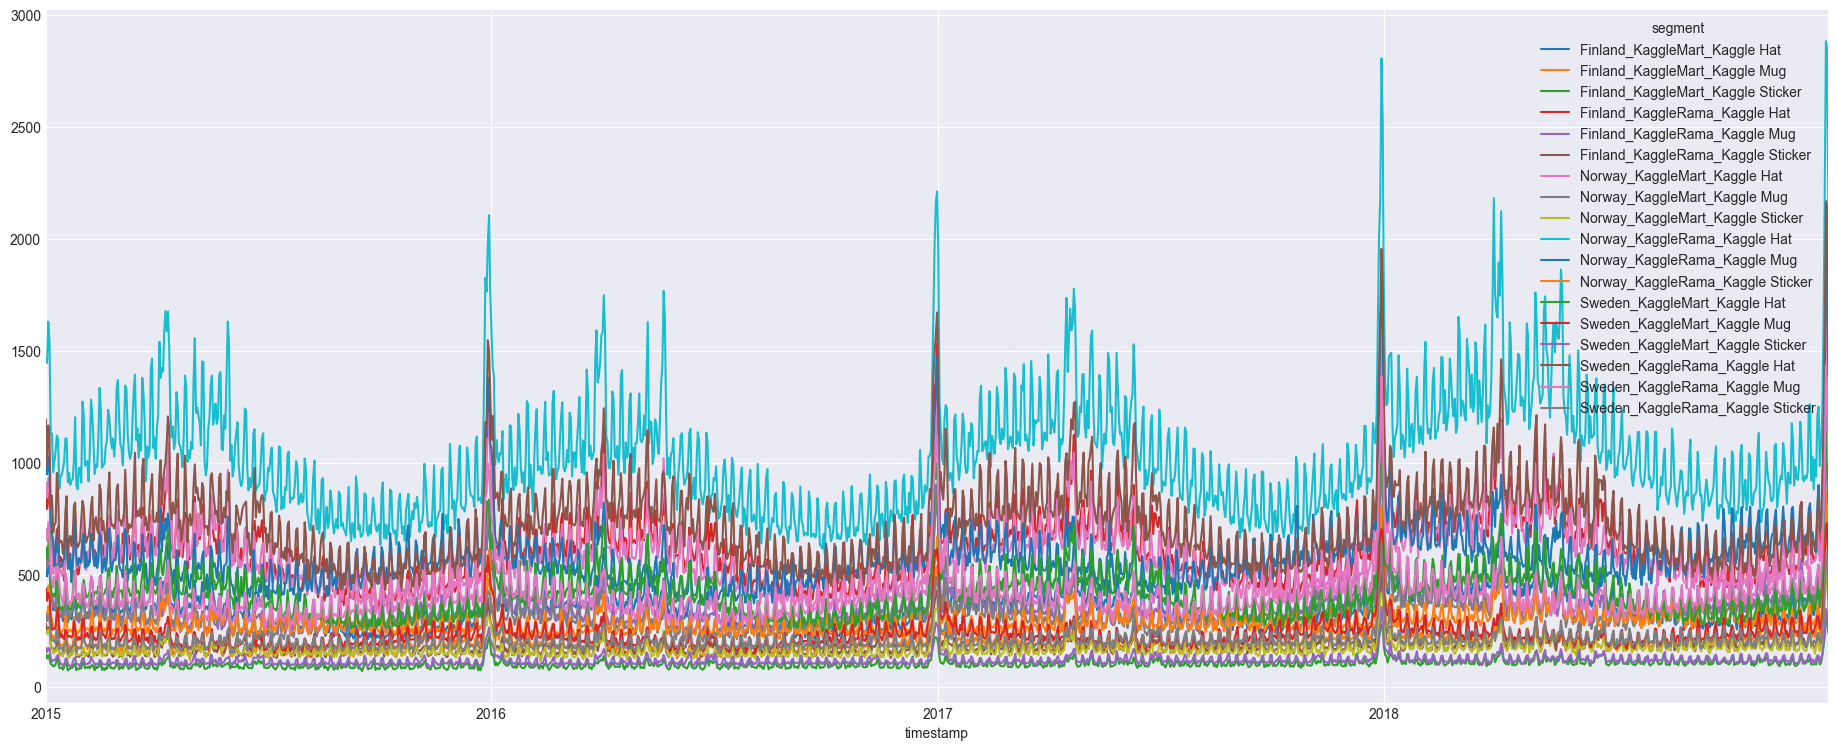

In [9]:
df_panel.plot();

Поэтому полезно смотреть ряды по отдельности.

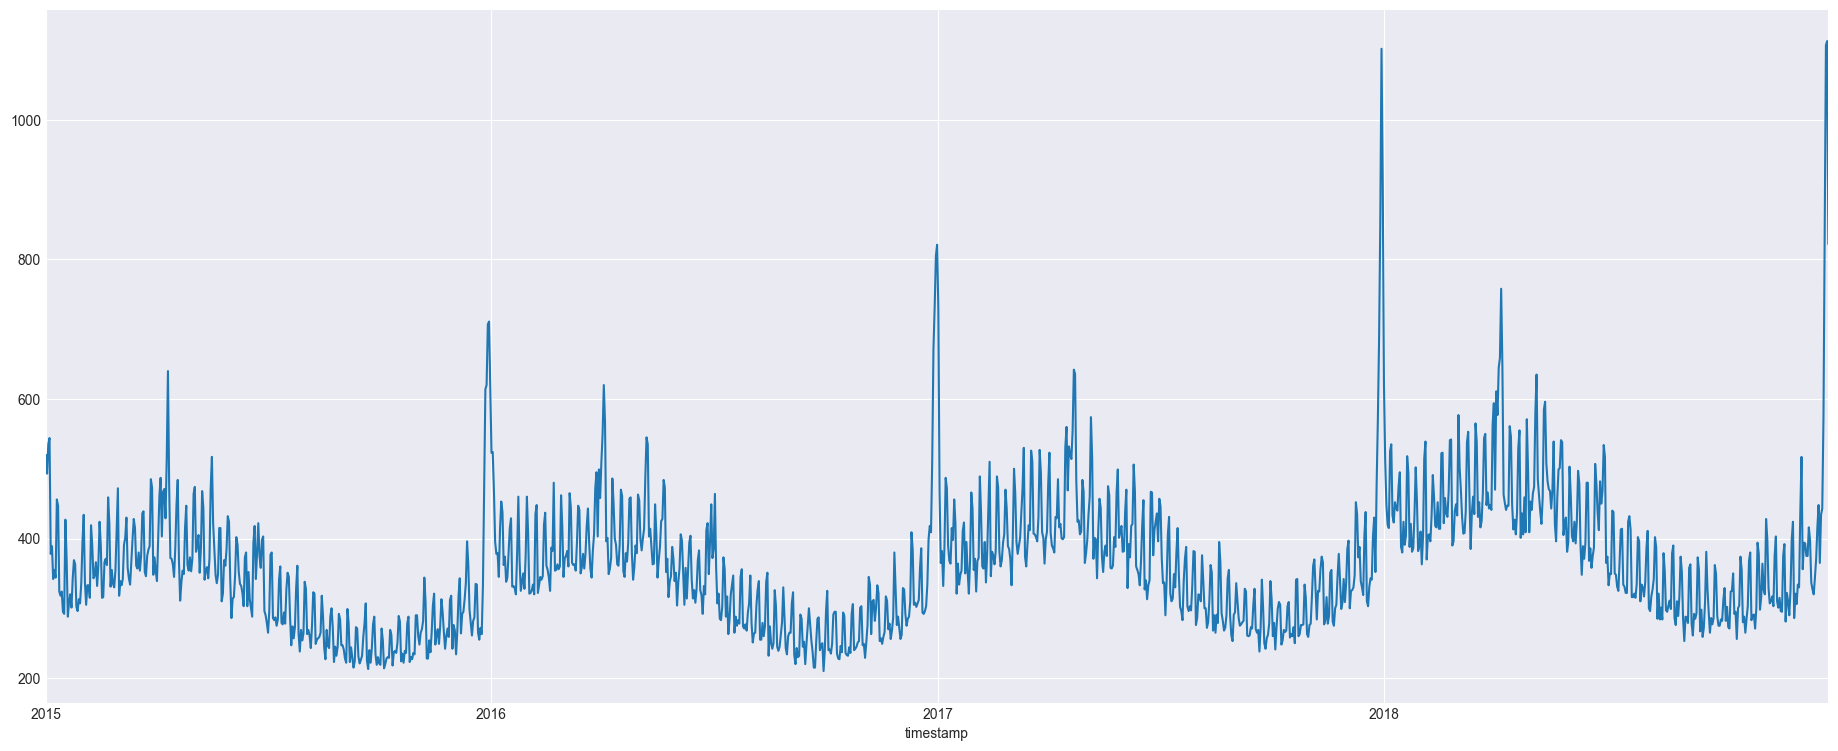

In [10]:
df_panel.loc[:, "Finland_KaggleMart_Kaggle Hat"].plot();

Удобно завести функцию, раскладывающую сегменты по сетке графиков.

In [11]:
def plot_panel(df, figsize=(25, 20)):
    segments = df.columns.tolist()
    random.shuffle(segments)

    rows_num = 6
    columns_num = 3

    _, ax = plt.subplots(rows_num, columns_num, figsize=figsize, squeeze=False, layout="tight")
    ax = ax.ravel()

    for i, segment in enumerate(segments):
        df_slice = df.loc[:, segment]
        ax[i].plot(df_slice.index, df_slice.values)
        ax[i].set_title(segment)

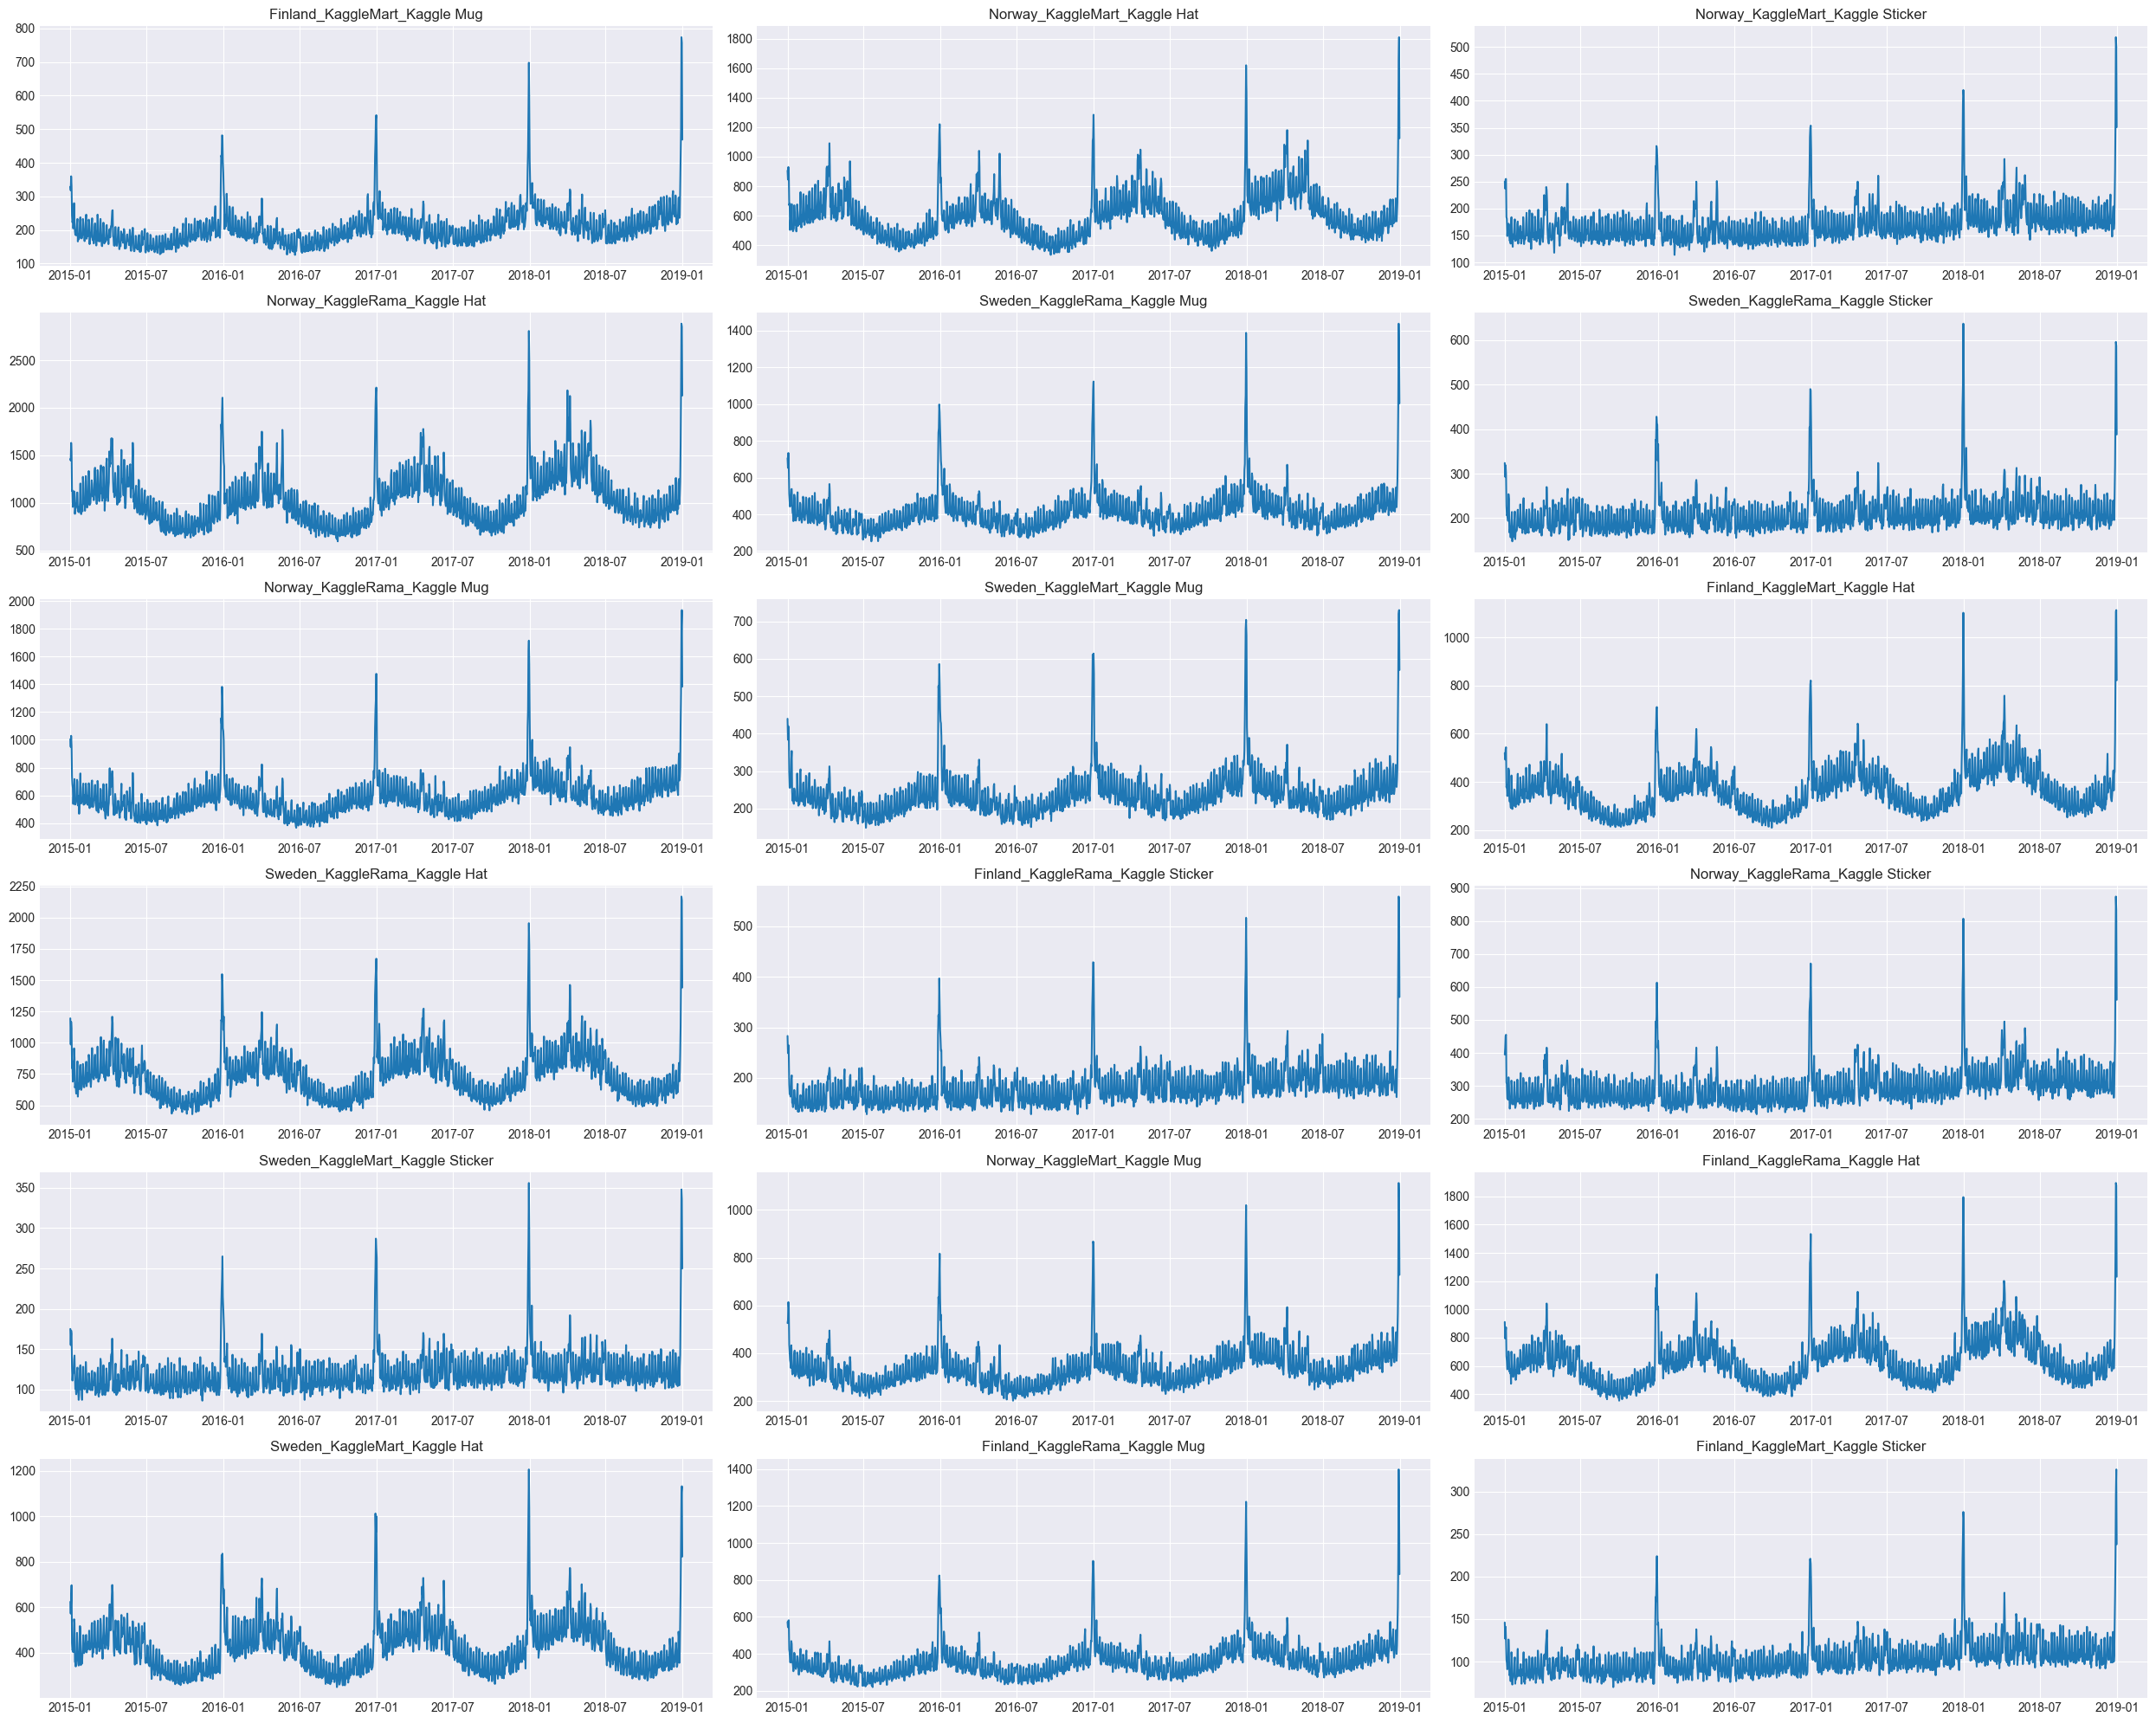

In [12]:
plot_panel(df_panel)

Иногда паттерны прячутся за шумом дневных данных. Сменим частотность на недельную, чтобы их разглядеть.

In [13]:
df_panel_weekly = df_panel.resample("W").sum()

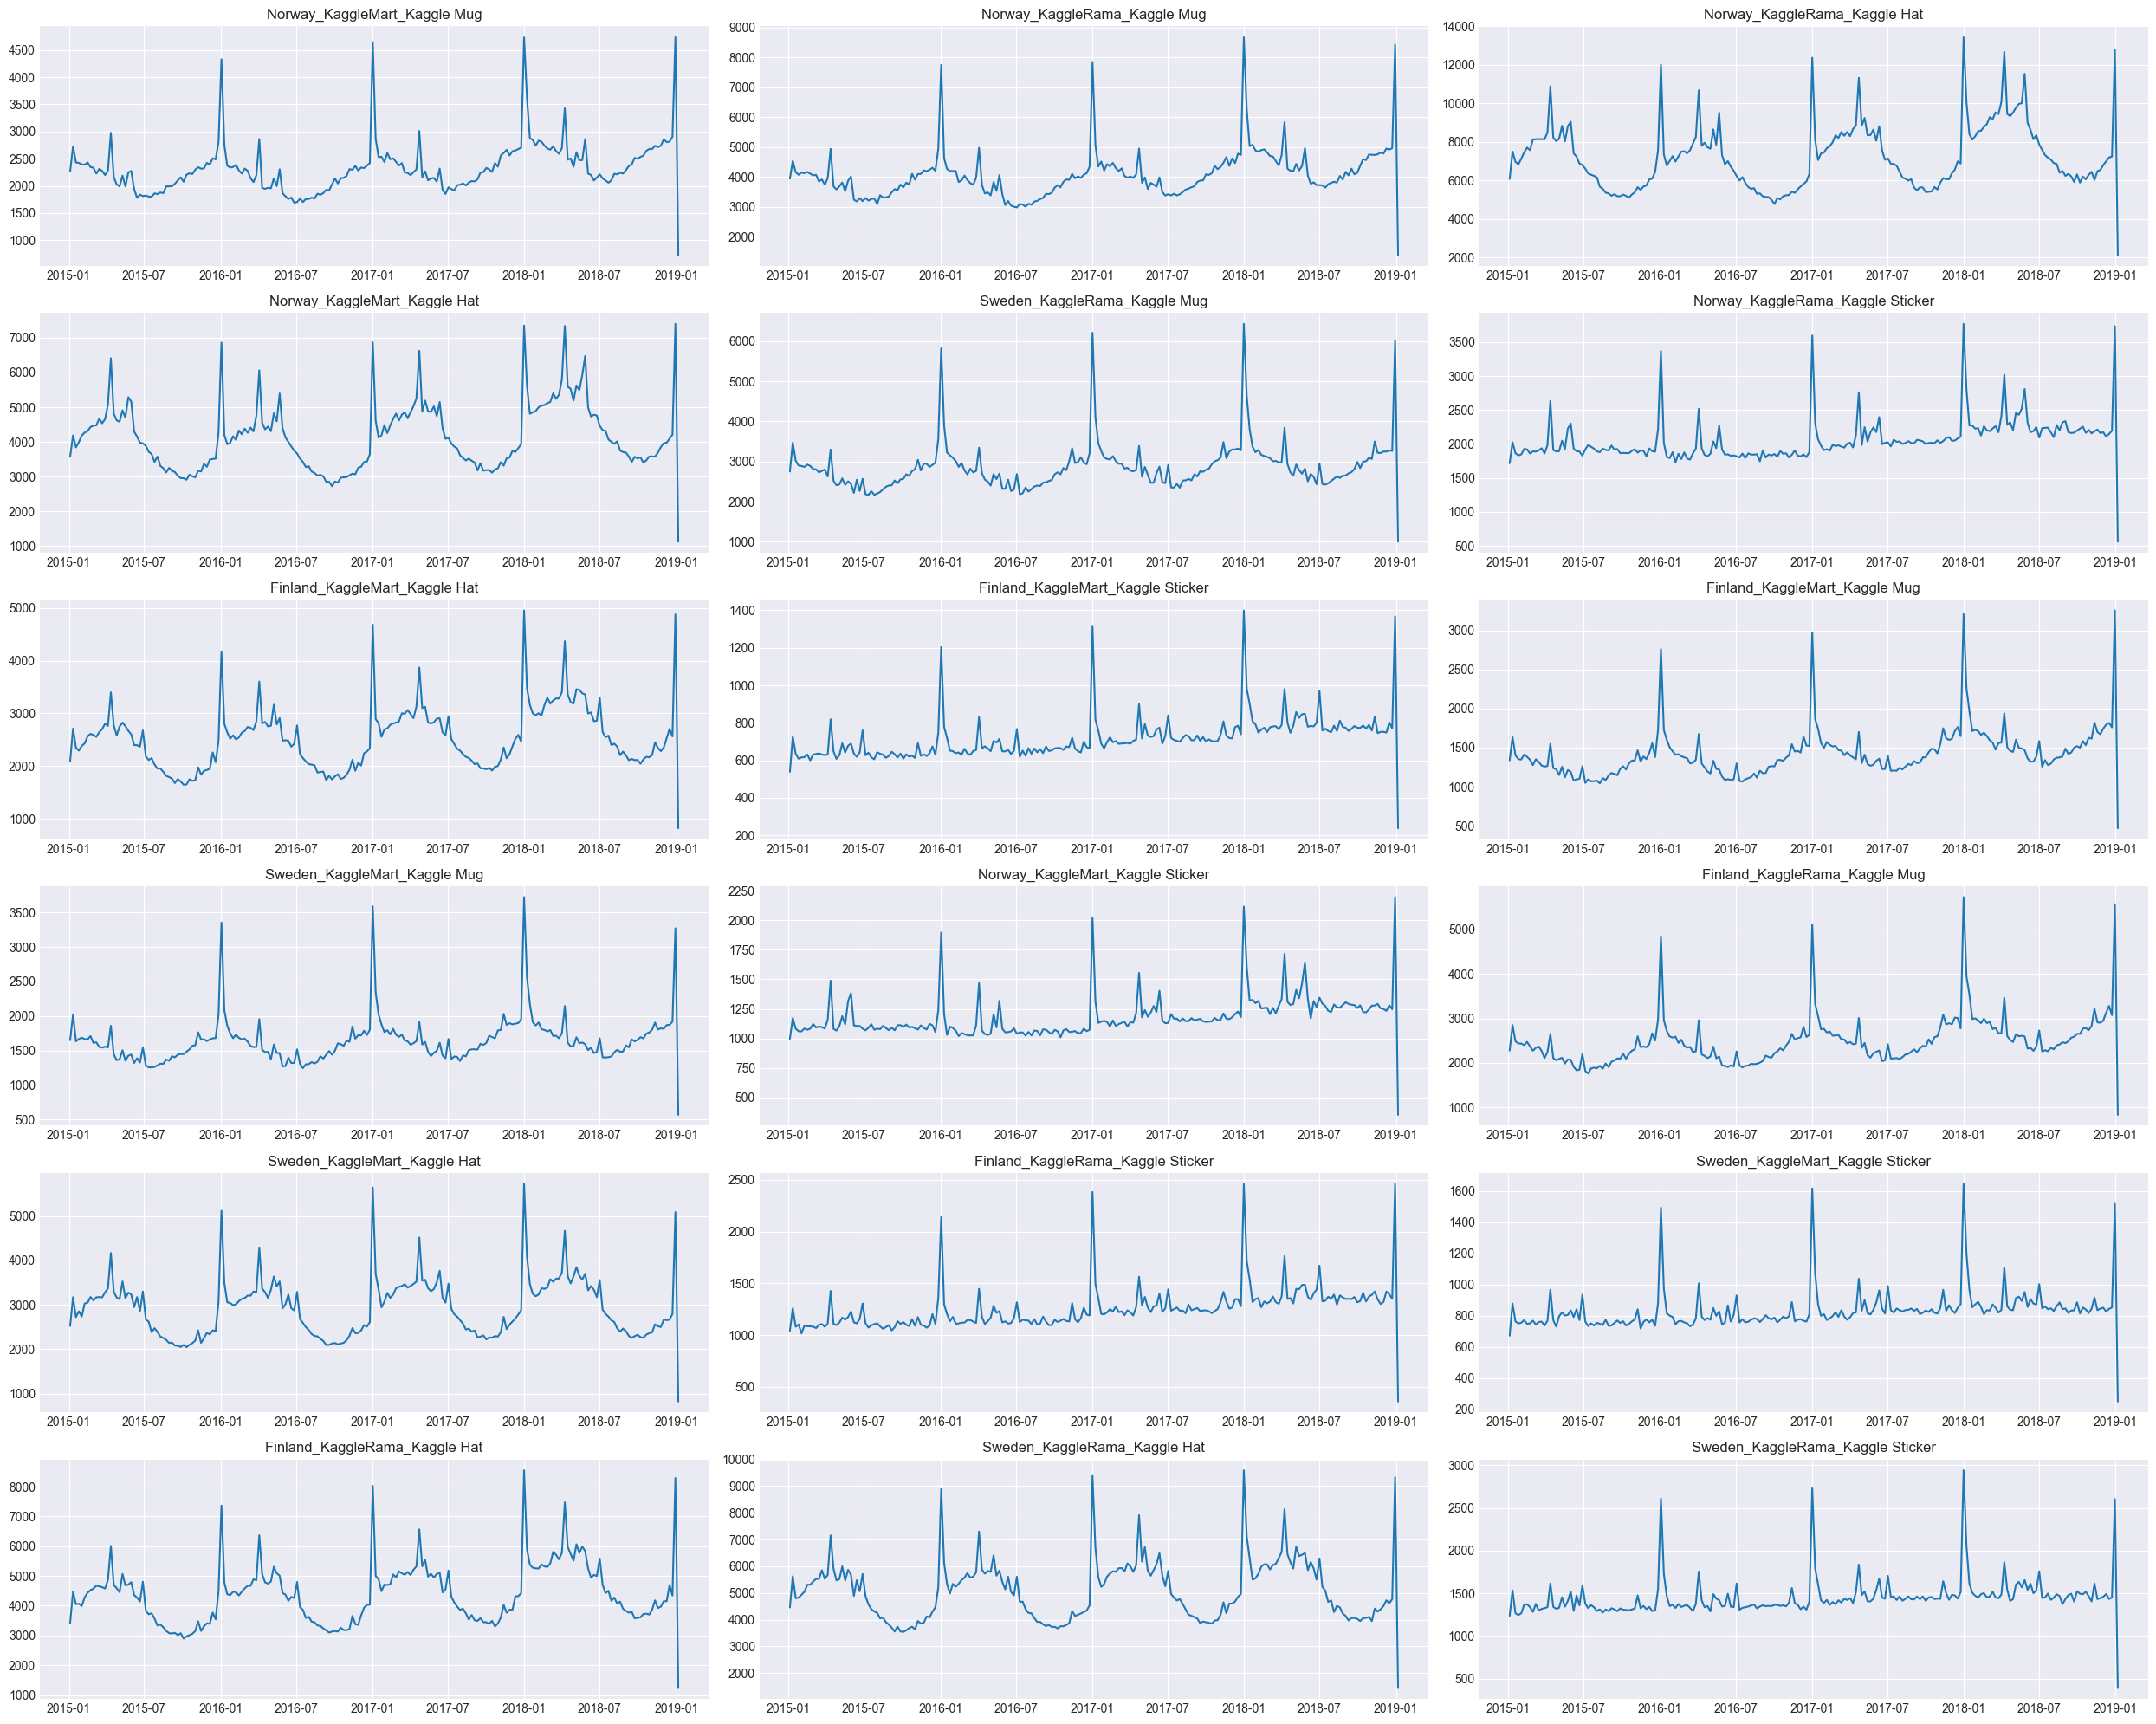

In [14]:
plot_panel(df_panel_weekly)

## 3. Panel Multivariate — несколько величин на экземпляр

Теперь для каждого сегмента измеряется не одна, а несколько величин. Колонки:
- `timestamp`;
- `segment`;
- `target_1, target_2, ...` — несколько измеряемых величин.

Такие дополнительные ряды часто выступают **экзогенными факторами** (погода, промо и т.п.). Возьмём погодные данные.

In [15]:
df_exog = pd.read_csv("https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/examples_data/nordics_weather.csv")
df_exog.head()

,timestamp,precipitation,snow_depth,tavg,tmax,tmin,segment
0,2015-01-01,1.714141,284.545455,1.428571,2.912739,-1.015287,Finland_KaggleMart_Kaggle Mug
1,2015-01-02,10.016667,195.000000,0.553571,2.358599,-0.998718,Finland_KaggleMart_Kaggle Mug
2,2015-01-03,3.956061,284.294118,-1.739286,0.820382,-3.463871,Finland_KaggleMart_Kaggle Mug
3,2015-01-04,0.246193,260.772727,-7.035714,-3.110828,-9.502581,Finland_KaggleMart_Kaggle Mug
4,2015-01-05,0.036364,236.900000,-17.164286,-8.727564,-19.004487,Finland_KaggleMart_Kaggle Mug


Развернём сразу по нескольким `values` — получим двухуровневые столбцы.

In [16]:
df_exog["timestamp"] = pd.to_datetime(df_exog["timestamp"])
df_exog = df_exog.pivot(
    index="timestamp",
    columns="segment",
    values=["precipitation", "snow_depth", "tavg", "tmax", "tmin"],
)
df_exog.head()

precipitation                                \
segment    Finland_KaggleMart_Kaggle Hat Finland_KaggleMart_Kaggle Mug   
timestamp                                                                
2015-01-01                      1.714141                      1.714141   
2015-01-02                     10.016667                     10.016667   
2015-01-03                      3.956061                      3.956061   
2015-01-04                      0.246193                      0.246193   
2015-01-05                      0.036364                      0.036364   

                                                                            \
segment    Finland_KaggleMart_Kaggle Sticker Finland_KaggleRama_Kaggle Hat   
timestamp                                                                    
2015-01-01                          1.714141                      1.714141   
2015-01-02                         10.016667                     10.016667   
2015-01-03                          3.956061                      3.956061   
2015-01-04                          0.246193                      0.246193   
2015-01-05                          0.036364                      0.036364   

                                                                            \
segment    Finland_KaggleRama_Kaggle Mug Finland_KaggleRama_Kaggle Sticker   
timestamp                                                                    
2015-01-01                      1.714141                          1.714141   
2015-01-02                     10.016667                         10.016667   
2015-01-03                      3.956061                          3.956061   
2015-01-04                      0.246193                          0.246193   
2015-01-05                      0.036364                          0.036364   

                                                                      \
segment    Norway_KaggleMart_Kaggle Hat Norway_KaggleMart_Kaggle Mug   
timestamp                                                              
2015-01-01                    13.731900                    13.731900   
2015-01-02                     8.494964                     8.494964   
2015-01-03                     4.054317                     4.054317   
2015-01-04                     3.025540                     3.025540   
2015-01-05                     2.039928                     2.039928   

                                                                          ...  \
segment    Norway_KaggleMart_Kaggle Sticker Norway_KaggleRama_Kaggle Hat  ...   
timestamp                                                                 ...   
2015-01-01                        13.731900                    13.731900  ...   
2015-01-02                         8.494964                     8.494964  ...   
2015-01-03                         4.054317                     4.054317  ...   
2015-01-04                         3.025540                     3.025540  ...   
2015-01-05                         2.039928                     2.039928  ...   

                                       tmin                               \
segment    Norway_KaggleMart_Kaggle Sticker Norway_KaggleRama_Kaggle Hat   
timestamp                                                                  
2015-01-01                         0.769369                     0.769369   
2015-01-02                        -0.066972                    -0.066972   
2015-01-03                        -1.756481                    -1.756481   
2015-01-04                        -3.545455                    -3.545455   
2015-01-05                        -5.254054                    -5.254054   

                                                                          \
segment    Norway_KaggleRama_Kaggle Mug Norway_KaggleRama_Kaggle Sticker   
timestamp                                                                  
2015-01-01                     0.769369                         0.769369   
2015-01-02                    -0.066972      

Переставим уровни столбцов так, чтобы сверху был сегмент, а под ним — величины, и отсортируем.

In [17]:
df_exog = df_exog.reorder_levels([1, 0], axis=1)
df_exog = df_exog.sort_index(axis=1, level=(0, 1))
df_exog.head()

segment    Finland_KaggleMart_Kaggle Hat                                   \
                           precipitation  snow_depth       tavg      tmax   
timestamp                                                                   
2015-01-01                      1.714141  284.545455   1.428571  2.912739   
2015-01-02                     10.016667  195.000000   0.553571  2.358599   
2015-01-03                      3.956061  284.294118  -1.739286  0.820382   
2015-01-04                      0.246193  260.772727  -7.035714 -3.110828   
2015-01-05                      0.036364  236.900000 -17.164286 -8.727564   

segment               Finland_KaggleMart_Kaggle Mug                         \
                 tmin                 precipitation  snow_depth       tavg   
timestamp                                                                    
2015-01-01  -1.015287                      1.714141  284.545455   1.428571   
2015-01-02  -0.998718                     10.016667  195.000000   0.553571   
2015-01-03  -3.463871                      3.956061  284.294118  -1.739286   
2015-01-04  -9.502581                      0.246193  260.772727  -7.035714   
2015-01-05 -19.004487                      0.036364  236.900000 -17.164286   

segment                          ... Sweden_KaggleRama_Kaggle Mug             \
                tmax       tmin  ...                precipitation snow_depth   
timestamp                        ...                                           
2015-01-01  2.912739  -1.015287  ...                     3.642278  84.924623   
2015-01-02  2.358599  -0.998718  ...                     2.414665  67.043702   
2015-01-03  0.820382  -3.463871  ...                     0.212793  79.945946   
2015-01-04 -3.110828  -9.502581  ...                     0.226833  78.997290   
2015-01-05 -8.727564 -19.004487  ...                     0.515601  79.736148   

segment                              Sweden_KaggleRama_Kaggle Sticker  \
            tavg      tmax      tmin                    precipitation   
timestamp                                                               
2015-01-01  3.47  5.415354  0.221569                         3.642278   
2015-01-02  3.80  5.097244  0.294882                         2.414665   
2015-01-03  1.61  2.140392 -1.776680                         0.212793   
2015-01-04 -1.35 -0.648425 -5.173123                         0.226833   
2015-01-05 -4.27 -3.027451 -9.544488                         0.515601   

segment                                          
           snow_depth  tavg      tmax      tmin  
timestamp                                        
2015-01-01  84.924623  3.47  5.415354  0.221569  
2015-01-02  67.043702  3.80  5.097244  0.294882  
2015-01-03  79.945946  1.61  2.140392 -1.776680  
2015-01-04  78.997290 -1.35 -0.648425 -5.173123  
2015-01-05  79.736148 -4.27 -3.027451 -9.544488  

[5 rows x 90 columns]

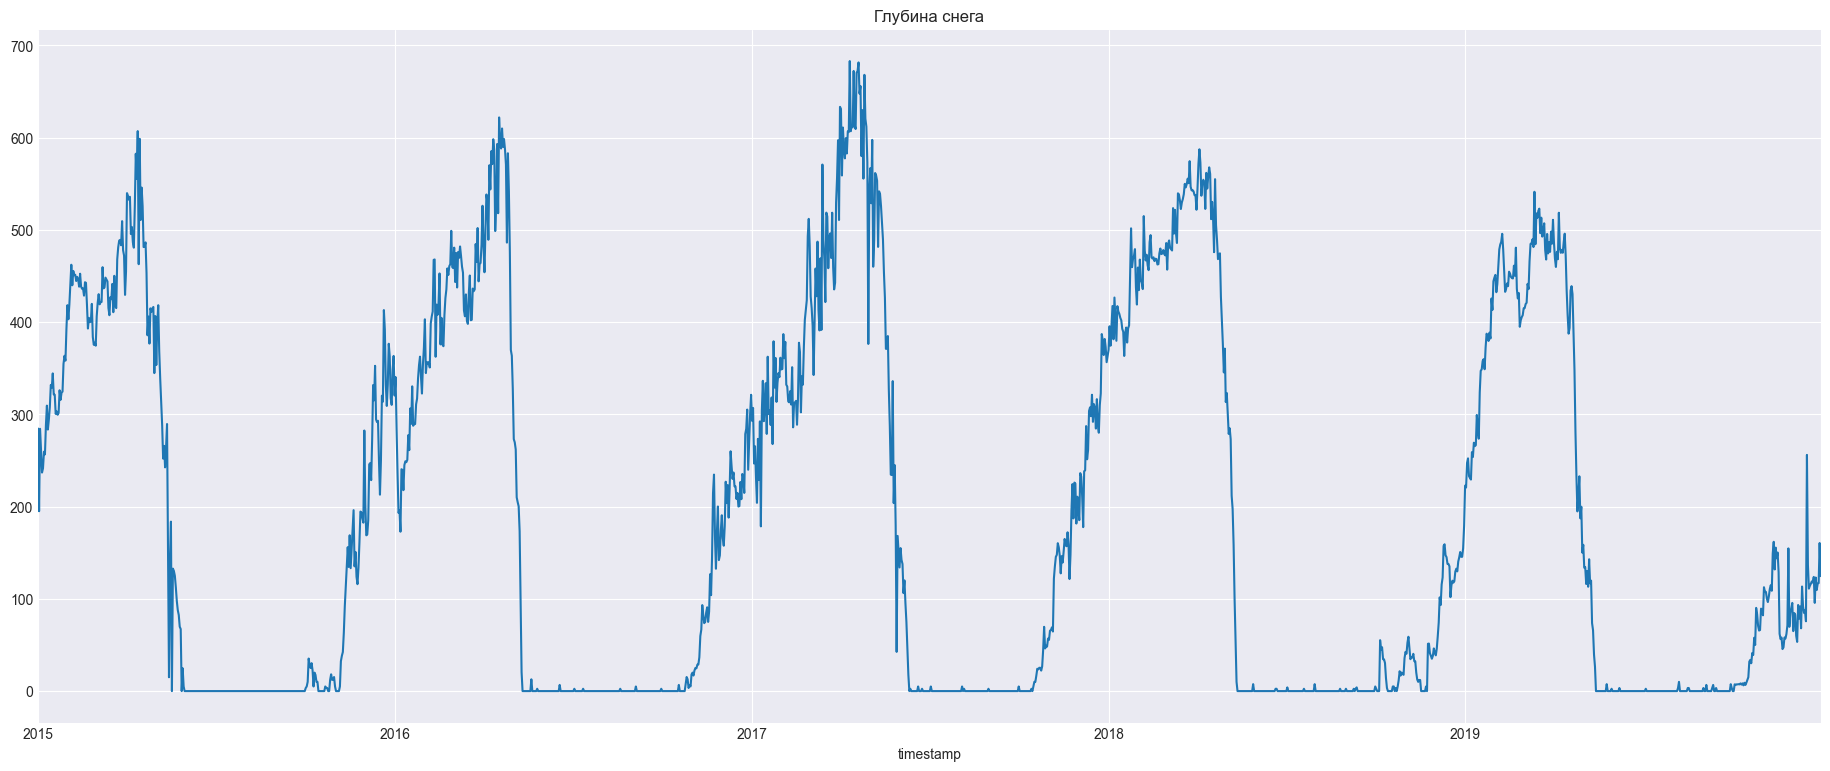

In [18]:
df_exog["Finland_KaggleMart_Kaggle Hat"]["snow_depth"].plot()
plt.title("Глубина снега");

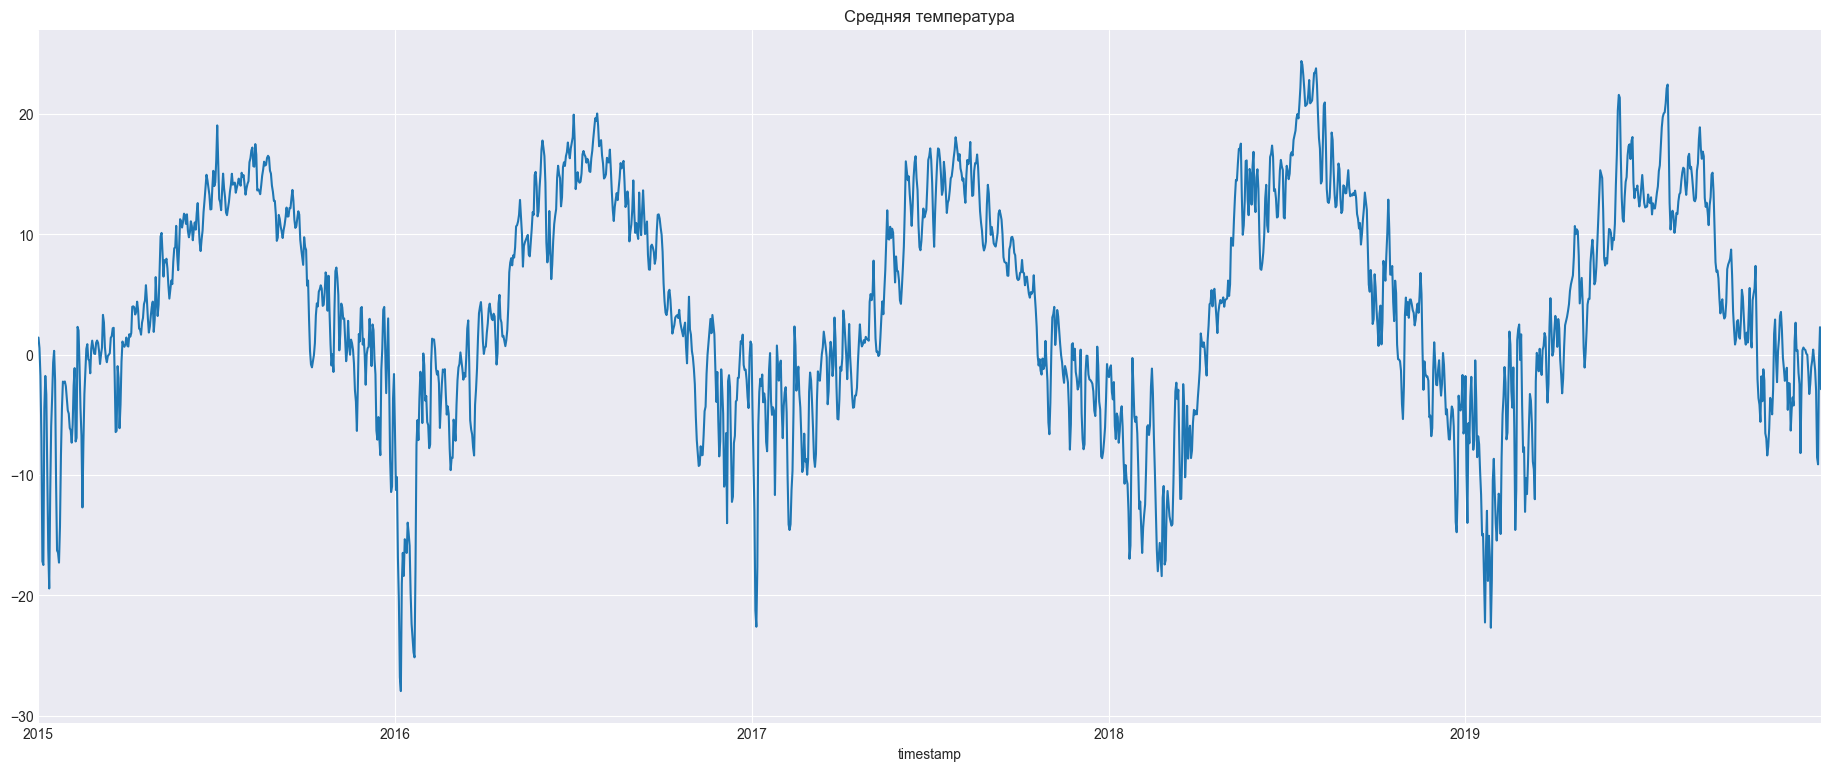

In [19]:
df_exog["Finland_KaggleMart_Kaggle Hat"]["tavg"].plot()
plt.title("Средняя температура");

## 4. Hierarchical / grouped — иерархическая структура

Ряды бывают вложены в дерево категорий. Колонки:
- `timestamp`;
- `level_1, level_2, ...` — категориальные колонки, задающие путь в дереве иерархии;
- `target`.

У нас — **групповая структура**: уровни иерархии можно переставлять местами:
- `country → market → product`
- `country → product → market`

In [20]:
df_group = pd.read_csv("https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/examples_data/nordic_merch_sales.csv")
df_group.head()

,timestamp,target,segment
0,2015-01-01,329,Finland_KaggleMart_Kaggle Mug
1,2015-01-01,520,Finland_KaggleMart_Kaggle Hat
2,2015-01-01,146,Finland_KaggleMart_Kaggle Sticker
3,2015-01-01,572,Finland_KaggleRama_Kaggle Mug
4,2015-01-01,911,Finland_KaggleRama_Kaggle Hat


In [21]:
df_group[["country", "market", "product"]] = (
    df_group["segment"].astype("string").str.split("_", expand=True)
)
df_group.head()

,timestamp,target,segment,country,market,product
0,2015-01-01,329,Finland_KaggleMart_Kaggle Mug,Finland,KaggleMart,Kaggle Mug
1,2015-01-01,520,Finland_KaggleMart_Kaggle Hat,Finland,KaggleMart,Kaggle Hat
2,2015-01-01,146,Finland_KaggleMart_Kaggle Sticker,Finland,KaggleMart,Kaggle Sticker
3,2015-01-01,572,Finland_KaggleRama_Kaggle Mug,Finland,KaggleRama,Kaggle Mug
4,2015-01-01,911,Finland_KaggleRama_Kaggle Hat,Finland,KaggleRama,Kaggle Hat


Поднимемся на уровень выше — суммируем продажи до `country + market`.

In [22]:
df_group_country_market_level = df_group.groupby(
    ["timestamp", "country", "market"], as_index=False
)["target"].sum()
df_group_country_market_level.head()

,timestamp,country,market,target
0,2015-01-01,Finland,KaggleMart,995
1,2015-01-01,Finland,KaggleRama,1766
2,2015-01-01,Norway,KaggleMart,1682
3,2015-01-01,Norway,KaggleRama,2861
4,2015-01-01,Sweden,KaggleMart,1239


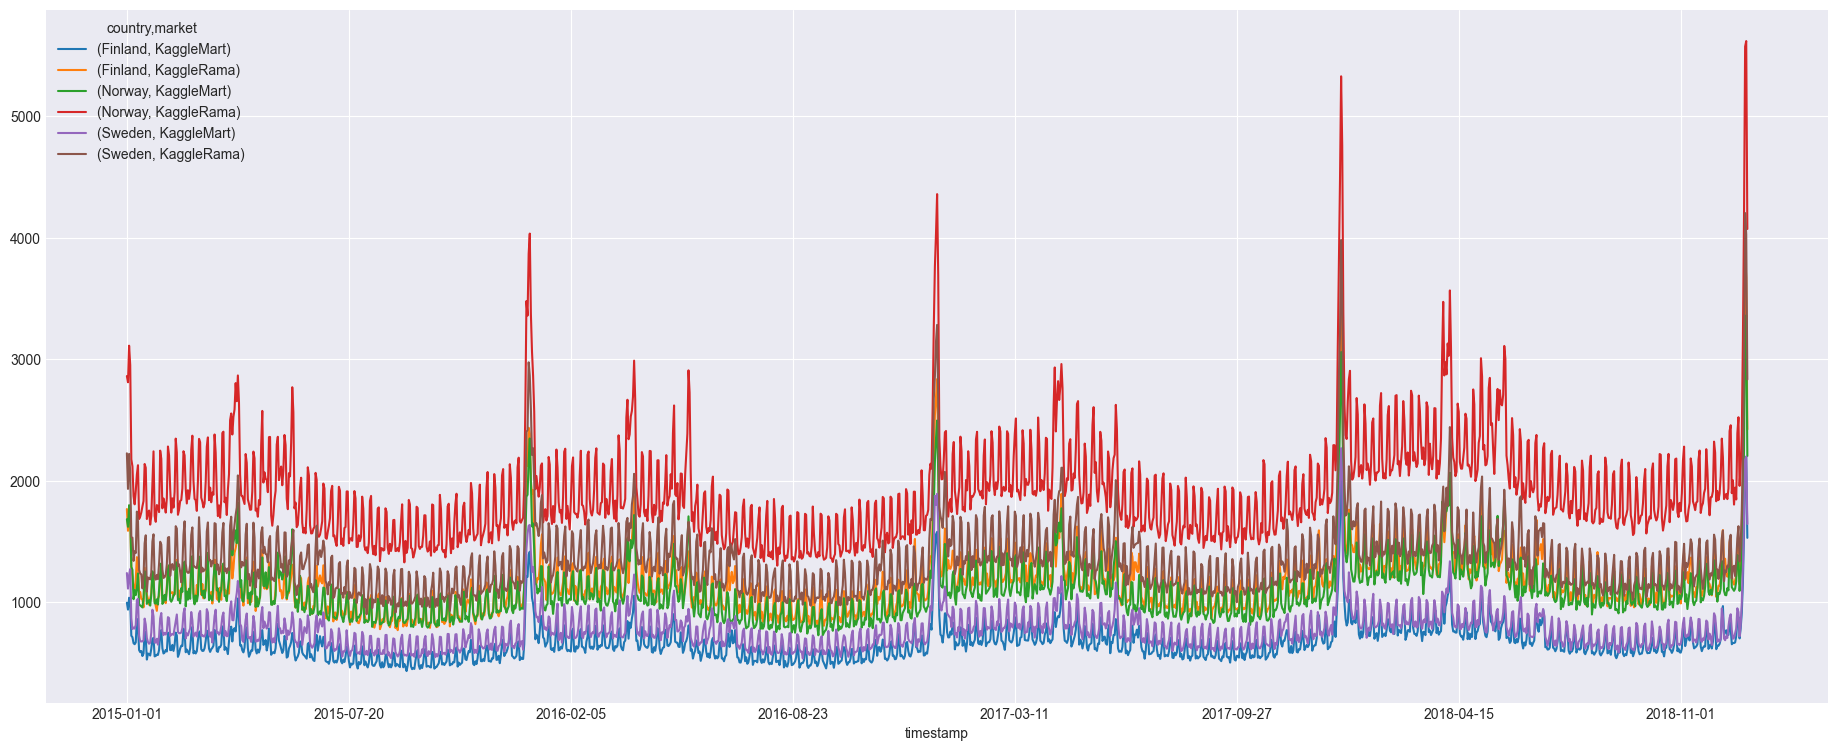

In [23]:
df_group_country_market_level.pivot(
    index="timestamp", columns=["country", "market"], values="target"
).plot();

Альтернативный порядок уровней — `country + product`.

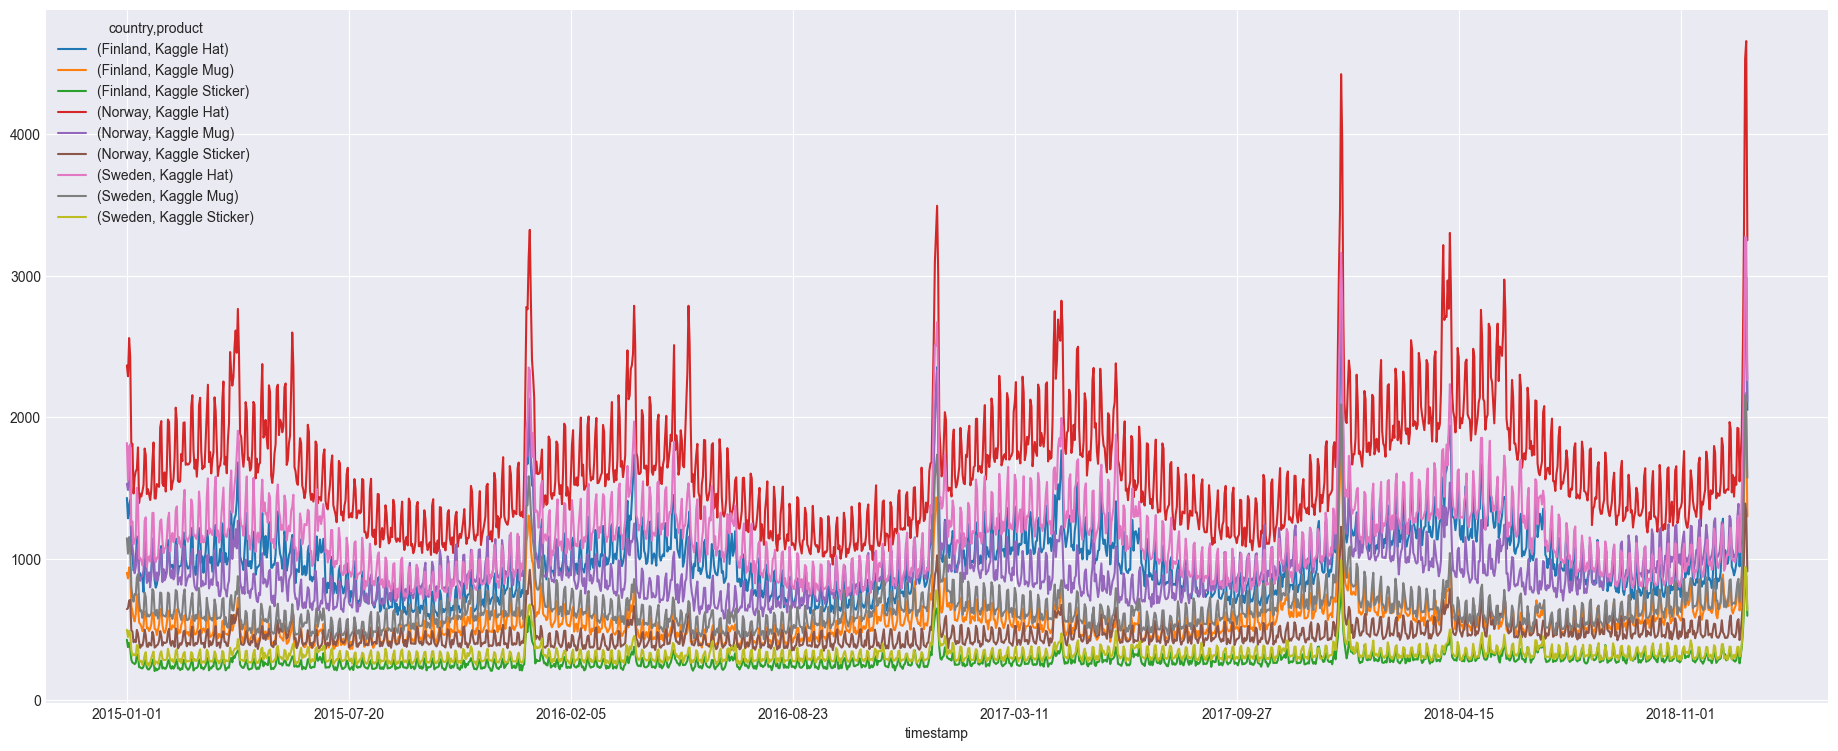

In [24]:
df_group_country_product_level = df_group.groupby(
    ["timestamp", "country", "product"], as_index=False
)["target"].sum()
df_group_country_product_level.pivot(
    index="timestamp", columns=["country", "product"], values="target"
).plot();

Ещё выше — только по странам.

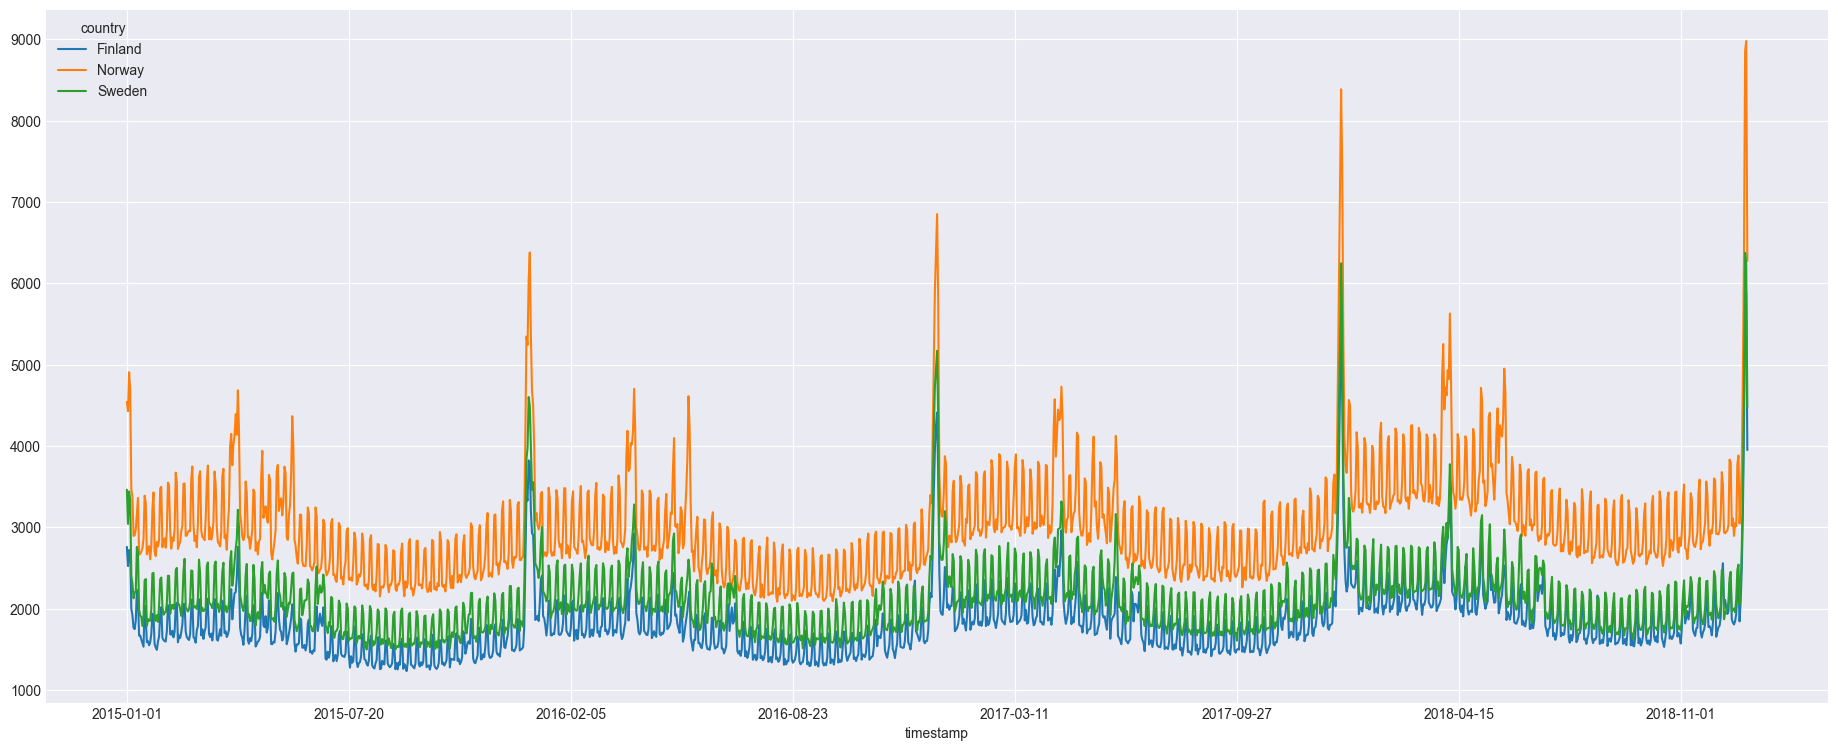

In [25]:
df_group_country_level = df_group.groupby(
    ["timestamp", "country"], as_index=False
)["target"].sum()
df_group_country_level.pivot(index="timestamp", columns="country", values="target").plot();

И самый верхний уровень — суммарные продажи всего подряд.

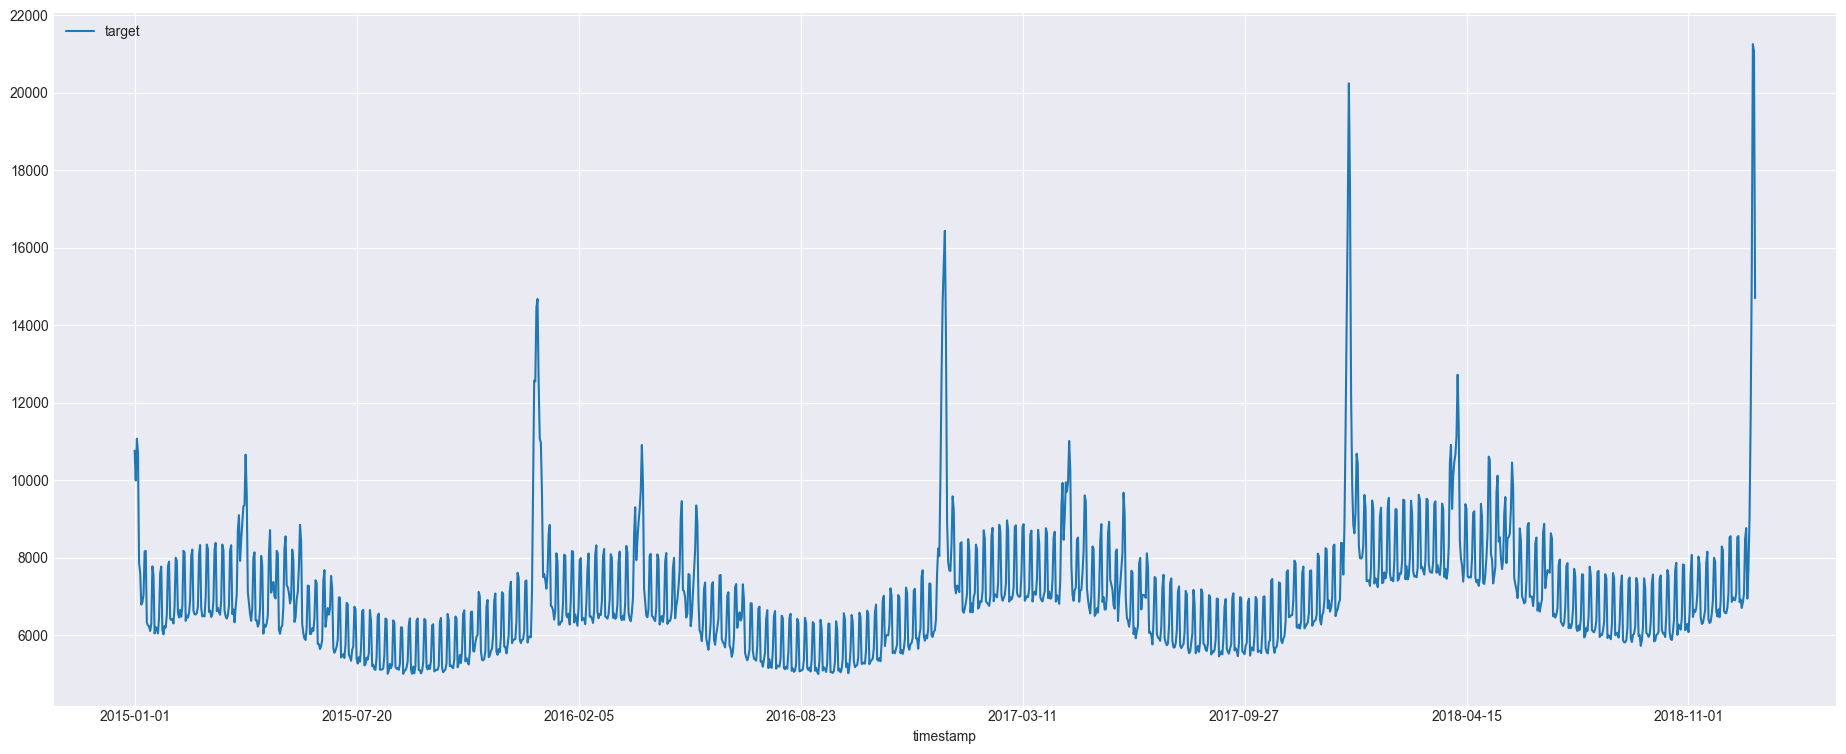

In [26]:
df_group_top_level = df_group.groupby(["timestamp"], as_index=False)["target"].sum()
df_group_top_level.set_index("timestamp").plot();

## Итог пункта

| Вид | Что описывает | Ключевые колонки |
|---|---|---|
| **Univariate** | один ряд | `timestamp`, `target` |
| **Panel** | много однотипных рядов | `timestamp`, `segment`, `target` |
| **Panel Multivariate** | несколько величин на сегмент | `timestamp`, `segment`, `target_1..k` |
| **Hierarchical / grouped** | ряды в дереве категорий | `timestamp`, `level_1..k`, `target` |

Мы научились приводить каждый из них к удобному для анализа виду (`pivot`, `resample`, агрегации по уровням). В **пункте 3** займёмся уже свойствами самих рядов — их **характеристиками**.